# Notebook 2 - Splitting the Data and Building Crops

This notebook takes the clean annotations from Notebook 1, splits the flights
into train, val and test, cuts out a small image of every animal (a crop), and
labels each crop as sharp or blurry and visible or occluded. The crops and labels
feed into the models in Notebook 3.

## Setup and Imports

Imports, folder paths, and the BAMBI class mapping again so this notebook can run
on its own.

In [1]:
import os
import cv2
import json
import random
import shutil
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# Paths
DATASET_PATH = Path("dataset")
REPORTS_PATH = Path("reports")
SPLIT_PATH   = Path("dataset_split")
CROPS_PATH   = Path("crops")

SPLIT_PATH.mkdir(exist_ok=True)
CROPS_PATH.mkdir(exist_ok=True)

# Full BAMBI 75-class mapping (from GitHub README)
BAMBI_CLASS_MAP = {
    "Q10738-0-0-0":0,  "Q10738-0-0-1":1,
    "Q1219579-0-0-0":2,"Q1219579-0-0-1":3,"Q1219579-0-1-0":4,"Q1219579-0-1-1":5,
    "Q1219579-0-2-0":6,"Q1219579-0-2-1":7,"Q1219579-1-0-0":8,"Q1219579-1-0-1":9,
    "Q1219579-1-2-0":10,"Q1219579-1-2-1":11,"Q1219579-2-0-0":12,"Q1219579-2-0-1":13,
    "Q1219579-2-1-0":14,"Q1219579-2-2-0":15,"Q1219579-2-2-1":16,
    "Q122069-0-0-0":17,"Q122069-0-0-1":18,"Q122069-0-1-0":19,"Q122069-0-1-1":20,
    "Q122069-0-2-0":21,"Q122069-0-2-1":22,
    "Q131340-0-0-0":23,"Q131340-0-0-1":24,"Q131340-0-2-0":25,"Q131340-0-2-1":26,
    "Q15978631-0-0-0":27,"Q15978631-0-0-1":28,"Q15978631-0-2-0":29,
    "Q15978631-0-2-1":30,"Q15978631-2-0-0":31,"Q15978631-2-2-0":32,"Q15978631-2-2-1":33,
    "Q168327-0-0-0":34,"Q168327-0-0-1":35,"Q168327-0-1-0":36,"Q168327-0-1-1":37,
    "Q168327-0-2-0":38,"Q168327-0-2-1":39,"Q168327-2-2-0":40,"Q168327-2-2-1":41,
    "Q20908334-0-0-0":42,"Q20908334-0-1-0":43,"Q20908334-1-0-0":44,
    "Q20908334-1-1-0":45,"Q20908334-1-2-0":46,"Q20908334-2-2-0":47,"Q20908334-2-2-1":48,
    "Q24238356-0-0-0":49,"Q24238356-0-0-1":50,"Q24238356-0-2-0":51,"Q24238356-0-2-1":52,
    "Q26972265-0-0-0":53,"Q26972265-0-2-0":54,"Q26972265-0-2-1":55,
    "Q5113-0-0-0":56,"Q5113-0-0-1":57,"Q5113-0-2-0":58,"Q5113-0-2-1":59,
    "Q58697-0-0-0":60,"Q58697-0-0-1":61,"Q58697-0-1-0":62,"Q58697-0-1-1":63,
    "Q58697-0-2-0":64,"Q58697-0-2-1":65,"Q58697-1-2-0":66,"Q58697-1-2-1":67,
    "Q58697-2-2-0":68,"Q58697-2-2-1":69,
    "Q602666-0-0-0":70,"Q602666-0-0-1":71,"Q602666-0-1-0":72,
    "Q602666-0-2-0":73,"Q602666-0-2-1":74,
}

SPECIES_NAMES = {
    "Q10738":"no-animal",    "Q1219579":"red-deer",  "Q122069":"roe-deer",
    "Q131340":"chamois",     "Q15978631":"human",    "Q168327":"alpine-ibex",
    "Q20908334":"fallow-deer","Q24238356":"unknown", "Q26972265":"dog",
    "Q5113":"bird",          "Q58697":"wild-boar",   "Q602666":"hybrid-pig",
}

VALID_CLASS_IDS = set(BAMBI_CLASS_MAP.values())

def class_id_to_label(class_id):
    for key, cid in BAMBI_CLASS_MAP.items():
        if cid == class_id:
            parts   = key.split("-")
            species = SPECIES_NAMES.get(parts[0], parts[0])
            gender  = {0:"unk",1:"male",2:"female"}[int(parts[1])]
            age     = {0:"unk",1:"juv",2:"adult"}[int(parts[2])]
            vis     = {0:"occluded",1:"visible"}[int(parts[3])]
            return f"{species}/{gender}/{age}/{vis}"
    return f"unknown_class_{class_id}"

def occlusion_from_class_id(class_id):
    """Returns 1=occluded, 0=visible, -1=not found."""
    for key, cid in BAMBI_CLASS_MAP.items():
        if cid == class_id:
            return 1 - int(key.split("-")[-1])
    return -1

def species_from_class_id(class_id):
    for key, cid in BAMBI_CLASS_MAP.items():
        if cid == class_id:
            return SPECIES_NAMES.get(key.split("-")[0], "unknown")
    return "unknown"

print("Imports OK")
print(f"Split output : {SPLIT_PATH.resolve()}")
print(f"Crops output : {CROPS_PATH.resolve()}")

Imports OK
Split output : C:\Users\dilya\Desktop\Computer_Vision\dataset_split
Crops output : C:\Users\dilya\Desktop\Computer_Vision\crops


## Load the Clean Annotations

We load the CSV that Notebook 1 produced and double check the columns we need are there.

In [2]:
df = pd.read_csv(REPORTS_PATH / "clean_annotations.csv")

# Hard check, modality column must exist from updated Week 1
if "modality" not in df.columns:
    raise ValueError(
        "'modality' column missing.\n"
        "   Re-run the updated Week 1 notebook (Change 5) first."
    )

print(f"Clean annotations : {len(df)}")
print(f"Unique images     : {df['image'].nunique()}")
print(f"Unique flights    : {df['flight_id'].nunique()}")
print(f"All thermal       : {(df['modality']=='thermal').all()} ← expected True for ALFS")

print(f"\nClass breakdown (top 15):")
for cid in df["class_id"].value_counts().head(15).index:
    count = (df["class_id"] == cid).sum()
    label = class_id_to_label(cid)
    bar   = "█" * min(35, int(count / 300))
    print(f"  [{cid:>2}] {count:>6}  {label:<45} {bar}")

print(f"\nFlight sizes (top 10):")
flight_sizes = df.groupby("flight_id")["image"].nunique().sort_values(ascending=False)
print(flight_sizes.head(10).to_string())

df.head()

Clean annotations : 55386
Unique images     : 17630
Unique flights    : 190
All thermal       : True ← expected True for ALFS

Class breakdown (top 15):
  [10]   6493  red-deer/male/adult/occluded                  █████████████████████
  [27]   4744  human/unk/unk/occluded                        ███████████████
  [ 2]   2727  red-deer/unk/unk/occluded                     █████████
  [16]   2715  red-deer/female/adult/visible                 █████████
  [ 3]   2390  red-deer/unk/unk/visible                      ███████
  [30]   2154  human/unk/adult/visible                       ███████
  [ 6]   1927  red-deer/unk/adult/occluded                   ██████
  [ 7]   1851  red-deer/unk/adult/visible                    ██████
  [28]   1832  human/unk/unk/visible                         ██████
  [43]   1775  fallow-deer/unk/juv/occluded                  █████
  [29]   1665  human/unk/adult/occluded                      █████
  [ 9]   1514  red-deer/male/unk/visible                     █████
  

,image,image_path,label_path,flight_id,frame_idx,class_id,x_center,y_center,width,height,box_area,aspect_ratio,validation_errors,is_valid,modality,class_label
0,152_14253.jpg,dataset\images\test\152_14253.jpg,dataset\labels\test\152_14253.txt,152,14253,2,0.746826,0.669189,0.004395,0.021973,0.000097,0.200000,[],True,thermal,red-deer (unknown/unknown/occluded)
1,152_14253.jpg,dataset\images\test\152_14253.jpg,dataset\labels\test\152_14253.txt,152,14253,2,0.743164,0.701660,0.014648,0.015625,0.000229,0.937500,[],True,thermal,red-deer (unknown/unknown/occluded)
2,152_14273.jpg,dataset\images\test\152_14273.jpg,dataset\labels\test\152_14273.txt,152,14273,2,0.742432,0.640137,0.005371,0.019531,0.000105,0.275000,[],True,thermal,red-deer (unknown/unknown/occluded)
3,152_14273.jpg,dataset\images\test\152_14273.jpg,dataset\labels\test\152_14273.txt,152,14273,2,0.735352,0.656494,0.016602,0.022949,0.000381,0.723404,[],True,thermal,red-deer (unknown/unknown/occluded)
4,152_14273.jpg,dataset\images\test\152_14273.jpg,dataset\labels\test\152_14273.txt,152,14273,2,0.726807,0.693359,0.018066,0.024414,0.000441,0.740000,[],True,thermal,red-deer (unknown/unknown/occluded)


## Flight Sizes and Tiny Flights

We count frames per flight again. Very small flights (under 20 frames) are not useful for testing, so we send them straight to the training set.

In [3]:
# Full flight inventory
frames_per_flight = df.groupby("flight_id")["image"].nunique().sort_values(ascending=False)

print(f"Total flights : {len(frames_per_flight)}")
print(f"Total images  : {frames_per_flight.sum()}")
print(f"Mean / flight : {frames_per_flight.mean():.1f}")
print(f"Min / flight  : {frames_per_flight.min()}")
print(f"Max / flight  : {frames_per_flight.max()}")

# Auto-assign tiny flights to train
# Flights with very few frames are not useful in val/test -
# they don't give enough examples to evaluate on meaningfully.
TINY_THRESHOLD = 20

tiny_flights   = frames_per_flight[frames_per_flight <  TINY_THRESHOLD].index.tolist()
normal_flights = frames_per_flight[frames_per_flight >= TINY_THRESHOLD].index.tolist()

print(f"\nFlights with < {TINY_THRESHOLD} frames (auto → train): {len(tiny_flights)}")
print(f"Flights to manually assign                          : {len(normal_flights)}")

print(f"\nNormal flights to assign (sorted by size):")
print(f"{'Flight ID':<15} {'Images':>8}")
print("-" * 25)
for fid in normal_flights:
    print(f"{str(fid):<15} {frames_per_flight[fid]:>8}")

Total flights : 190
Total images  : 17630
Mean / flight : 92.8
Min / flight  : 5
Max / flight  : 603

Flights with < 20 frames (auto → train): 19
Flights to manually assign                          : 171

Normal flights to assign (sorted by size):
Flight ID         Images
-------------------------
17                   603
31                   534
28                   393
140                  329
142                  289
143                  287
34                   264
123                  229
246                  228
10                   224
6                    210
224                  206
22                   205
13                   192
55                   189
106                  188
141                  185
225                  181
15                   180
18                   170
105                  170
104                  169
276                  168
193                  159
192                  158
194                  154
120                  152
176                  151
1

## Assign Flights to Train, Val and Test

We split by whole flight, not by single frame, so that near identical frames from the same flight never end up on both sides. The lists below decide which flight goes where, aiming for roughly 70/15/15.

In [4]:

# READ:
# only flights from 'normal_flights' here
# tiny flights are handled automatically at the bottom
# every normal flight must appear in exactly one list
# around ~70% images in train, ~15% val, ~15% test.
# flight 17 (1125 frames, cold-background thermal) -: TRAIN
# check class coverage in cell 5 before proceeding


TRAIN_FLIGHTS_MANUAL = [
    17, 31, 28,  0, 21, 26, 27, 29, 32, 56, 66, 102, 103, 111, 112, 114, 115, 117, 118, 129, 130, 131,
    132, 134, 136, 137, 138, 139, 144, 145, 146, 147, 151, 152, 159, 163, 177, 178, 179, 180, 181, 182, 
    184, 186, 187, 188, 189, 190, 191, 198, 199, 201, 202, 204, 205, 206, 210, 211, 212, 215, 216, 221, 
    222, 223, 226, 227, 228, 230, 231, 236, 237, 238, 240, 241, 245, 248, 249, 251, 252, 256, 260, 261, 
    262, 263, 264, 265, 266, 267, 277, 278, 279, 280, 281, 294, 295, 296, 297, 298, 299, 300, 301, 302, 
    306, 308, 309, 314, 343, 344, 345, 346, 347, 348, 349, 141, 225, 15, 105, 18, 104, 276, 229, 20, 14, 
    101, 242, 235, 140, 142, 143, 34
]

# Suggested val flights (medium-sized, mix of species)
VAL_FLIGHTS_MANUAL = [
    22, 123, 246, 10, 6, 224,
    13, 55, 106, 119, 193, 192, 194, 120, 176, 161, 122, 196, 155
]

# Suggested test flights (medium-sized, no tiny flights)
TEST_FLIGHTS_MANUAL = [
    150, 197, 121, 162, 195, 1, 100, 116, 284, 247,
    243, 234, 135, 232, 113, 250, 282, 244, 283, 175, 183, 156, 213, 124
]

# Auto-add tiny flights to train
TRAIN_FLIGHTS = list(set(TRAIN_FLIGHTS_MANUAL + tiny_flights))
VAL_FLIGHTS   = list(set(VAL_FLIGHTS_MANUAL))
TEST_FLIGHTS  = list(set(TEST_FLIGHTS_MANUAL))

# Validation
all_flights    = set(df["flight_id"].unique())
assigned       = set(TRAIN_FLIGHTS) | set(VAL_FLIGHTS) | set(TEST_FLIGHTS)
unassigned     = all_flights - assigned
double_assigned = (
    (set(TRAIN_FLIGHTS) & set(VAL_FLIGHTS)) |
    (set(TRAIN_FLIGHTS) & set(TEST_FLIGHTS)) |
    (set(VAL_FLIGHTS)   & set(TEST_FLIGHTS))
)

if unassigned:
    print(f"Unassigned flights ({len(unassigned)}): {sorted(unassigned)}")
elif double_assigned:
    print(f"Flights in multiple splits: {sorted(double_assigned)}")
else:
    train_imgs = df[df["flight_id"].isin(TRAIN_FLIGHTS)]["image"].nunique()
    val_imgs   = df[df["flight_id"].isin(VAL_FLIGHTS)]["image"].nunique()
    test_imgs  = df[df["flight_id"].isin(TEST_FLIGHTS)]["image"].nunique()
    total      = train_imgs + val_imgs + test_imgs

    print("All flights assigned. No overlaps.")
    print(f"\n  Train : {train_imgs:>5} images  ({100*train_imgs/total:.1f}%)  "
          f"- {len(TRAIN_FLIGHTS)} flights")
    print(f"  Val   : {val_imgs:>5} images  ({100*val_imgs/total:.1f}%)  "
          f"- {len(VAL_FLIGHTS)} flights")
    print(f"  Test  : {test_imgs:>5} images  ({100*test_imgs/total:.1f}%)  "
          f"- {len(TEST_FLIGHTS)} flights")

Flights in multiple splits: [243]


## Check Every Class Appears in Every Split

We make sure no split is missing a species, otherwise we could not evaluate that species properly.

In [ ]:
all_classes = sorted(df["class_id"].unique())
splits = {"train": TRAIN_FLIGHTS, "val": VAL_FLIGHTS, "test": TEST_FLIGHTS}

print("Class coverage per split:\n")
any_problem = False

for split_name, flight_list in splits.items():
    split_df = df[df["flight_id"].isin(flight_list)]
    present  = sorted(split_df["class_id"].unique())
    missing  = [c for c in all_classes if c not in present]

    if missing:
        print(f"  {split_name:<6}  MISSING {len(missing)} classes: {missing}")
        print(f"         Reassign flights until all classes appear in all splits.")
        any_problem = True
    else:
        print(f"  {split_name:<6}  all {len(present)} classes present")

# Extra: flag very rare classes (< 10 annotations in train)
print("\nRare class check in train split:")
train_df = df[df["flight_id"].isin(TRAIN_FLIGHTS)]
for cid in all_classes:
    count = (train_df["class_id"] == cid).sum()
    if count < 10:
        label = class_id_to_label(cid)
        print(f"   Class {cid:>2} ({label}) has only {count} training annotations")

if not any_problem:
    print("\nAll classes present in all splits. Safe to proceed.")

Class coverage per split:

  train   MISSING 1 classes: [np.int64(52)]
         Reassign flights until all classes appear in all splits.
  val     MISSING 19 classes: [np.int64(17), np.int64(18), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(31), np.int64(32), np.int64(37), np.int64(38), np.int64(42), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(51), np.int64(53), np.int64(54)]
         Reassign flights until all classes appear in all splits.
  test    MISSING 16 classes: [np.int64(5), np.int64(11), np.int64(14), np.int64(19), np.int64(29), np.int64(33), np.int64(35), np.int64(36), np.int64(40), np.int64(41), np.int64(45), np.int64(48), np.int64(50), np.int64(51), np.int64(52), np.int64(53)]
         Reassign flights until all classes appear in all splits.

Rare class check in train split:
   Class 48 (fallow-deer/female/adult/visible) has only 4 training annotations
   Class 52 (unknown/unk/adult/visible) has only 0 training annotat

## Reset the Split Folder

We clear out any old split so we always start fresh.

In [6]:
import shutil

if SPLIT_PATH.exists():
    shutil.rmtree(SPLIT_PATH)

SPLIT_PATH.mkdir()

## Copy Images and Labels into the Split Folders

We copy each image and its label into the right train, val or test folder. This is what YOLO reads for detection training.

In [7]:
def get_split_for_flight(flight_id):
    if flight_id in TRAIN_FLIGHTS: return "train"
    if flight_id in VAL_FLIGHTS:   return "val"
    if flight_id in TEST_FLIGHTS:  return "test"
    return None

# Create folder tree
for split in ["train", "val", "test"]:
    (SPLIT_PATH / split / "images").mkdir(parents=True, exist_ok=True)
    (SPLIT_PATH / split / "labels").mkdir(parents=True, exist_ok=True)

print("Folder structure created:")
for split in ["train", "val", "test"]:
    print(f"  {SPLIT_PATH}/{split}/images/")
    print(f"  {SPLIT_PATH}/{split}/labels/")

# Copy files
copied  = {"train": 0, "val": 0, "test": 0}
skipped = 0

unique_pairs = df[["image_path", "label_path", "flight_id"]].drop_duplicates(subset="image_path")
print(f"\nCopying {len(unique_pairs)} image-label pairs...")

for _, row in unique_pairs.iterrows():
    split = get_split_for_flight(row["flight_id"])
    if split is None:
        skipped += 1
        continue

    img_src   = Path(row["image_path"])
    label_src = Path(row["label_path"])
    img_dst   = SPLIT_PATH / split / "images" / img_src.name
    label_dst = SPLIT_PATH / split / "labels" / label_src.name

    shutil.copy2(img_src, img_dst)
    if label_src.exists():
        shutil.copy2(label_src, label_dst)
    copied[split] += 1

print(f"\nFiles copied:")
print(f"  Train : {copied['train']}")
print(f"  Val   : {copied['val']}")
print(f"  Test  : {copied['test']}")
if skipped:
    print(f"   Skipped (unassigned): {skipped}")

Folder structure created:
  dataset_split/train/images/
  dataset_split/train/labels/
  dataset_split/val/images/
  dataset_split/val/labels/
  dataset_split/test/images/
  dataset_split/test/labels/

Copying 17630 image-label pairs...

Files copied:
  Train : 11675
  Val   : 3243
  Test  : 2712


## Choose the Classes and Write the Dataset File

We collapse the detailed BAMBI classes down to species level and drop the non animal classes. Then we write the dataset.yaml file that tells YOLO the class names.

In [8]:
# still to choose
# "binary"  -> 1 class: "animal"  - simplest, trains fastest
# "species"  12 classes by species - recommended for your project
# "full"    → all 54+ BAMBI classes - too complex for this subset


class_strategy = "species"   # ← CHANGE THIS

if class_strategy == "binary":
    CLASS_NAMES = {0: "animal"}

elif class_strategy == "species":
    # One class per species - collapse gender/age/visibility into species name
    # Exclude non-detectable "classes": you can't draw a box around "no animal",
    # and "unknown" is not a real species. Removing them lifts mAP and is correct.
    EXCLUDE_SPECIES = {"no-animal", "unknown"}
    unique_species = sorted(set(
        species_from_class_id(cid) for cid in df["class_id"].unique()
    ) - EXCLUDE_SPECIES)
    CLASS_NAMES = {i: name for i, name in enumerate(unique_species)}

    print("Species classes:")
    for cid, name in CLASS_NAMES.items():
        count = sum(
            (df["class_id"] == bcid).sum()
            for bcid in df["class_id"].unique()
            if species_from_class_id(bcid) == name
        )
        print(f"  [{cid}] {name:<20} {count} annotations")

elif class_strategy == "full":
    present_ids = sorted(df["class_id"].unique())
    CLASS_NAMES = {i: class_id_to_label(cid) for i, cid in enumerate(present_ids)}
    print(f"Full strategy: {len(CLASS_NAMES)} classes (not recommended)")

# Write YAML
dataset_yaml = {
    "path"  : str(SPLIT_PATH.resolve()),
    "train" : "train/images",
    "val"   : "val/images",
    "test"  : "test/images",
    "nc"    : len(CLASS_NAMES),
    "names" : CLASS_NAMES,
}

yaml_path = SPLIT_PATH / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print(f"\ndataset.yaml written - nc={len(CLASS_NAMES)}")
print(f"   Path: {yaml_path}")
with open(yaml_path) as f:
    print(f.read())

Species classes:
  [0] alpine-ibex          3348 annotations
  [1] chamois              2385 annotations
  [2] dog                  846 annotations
  [3] fallow-deer          3777 annotations
  [4] human                11937 annotations
  [5] red-deer             26843 annotations
  [6] roe-deer             3044 annotations

dataset.yaml written - nc=7
   Path: dataset_split\dataset.yaml
path: C:\Users\dilya\Desktop\Computer_Vision\dataset_split
train: train/images
val: val/images
test: test/images
nc: 7
names:
  0: alpine-ibex
  1: chamois
  2: dog
  3: fallow-deer
  4: human
  5: red-deer
  6: roe-deer



## Check the Split Folders

A quick check that every image has a matching label in each split.

In [10]:
print("Verifying split folder contents:\n")

for split in ["train", "val", "test"]:
    img_folder   = SPLIT_PATH / split / "images"
    label_folder = SPLIT_PATH / split / "labels"
    imgs         = list(img_folder.glob("*"))
    labels       = list(label_folder.glob("*.txt"))
    img_stems    = {f.stem for f in imgs}
    label_stems  = {f.stem for f in labels}
    missing      = img_stems - label_stems

    print(f"  {split.upper()}")
    print(f"Images         : {len(imgs)}")
    print(f"Labels         : {len(labels)}")
    if missing:
        print(f"{len(missing)} images have no matching label")
    else:
        print(f"Every image has a matching label")
    print()

Verifying split folder contents:

  TRAIN
Images         : 11675
Labels         : 11675
Every image has a matching label

  VAL
Images         : 3243
Labels         : 3243
Every image has a matching label

  TEST
Images         : 2712
Labels         : 2712
Every image has a matching label



## Cut Out a Crop for Every Animal

For each box we cut out a small padded image of the animal and save it. These crops are what the sharpness and occlusion classifiers learn from. We save them as PNG so we do not lose any detail.

In [11]:
PADDING = 0.05  # 5% padding around each box

crop_records = []
failed_crops = []

grouped = df.groupby("image_path")
print(f"Cropping {len(df)} annotations from {df['image_path'].nunique()} images...")

for img_path_str, group in grouped:
    img_path = Path(img_path_str)
    img      = cv2.imread(str(img_path))

    if img is None:
        failed_crops.append(img_path_str)
        continue

    # All images are thermal - display as grayscale
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h_img, w_img = gray.shape[:2]

    for box_idx, row in enumerate(group.itertuples()):
        x, y, w, h = row.x_center, row.y_center, row.width, row.height

        # Add padding, clamp to [0, 1]
        x1_n = max(0.0, x - w/2 - PADDING)
        y1_n = max(0.0, y - h/2 - PADDING)
        x2_n = min(1.0, x + w/2 + PADDING)
        y2_n = min(1.0, y + h/2 + PADDING)

        x1, y1 = int(x1_n * w_img), int(y1_n * h_img)
        x2, y2 = int(x2_n * w_img), int(y2_n * h_img)

        if x2 <= x1 or y2 <= y1:
            continue

        crop      = gray[y1:y2, x1:x2]
        split     = get_split_for_flight(row.flight_id)
        crop_name = f"{img_path.stem}__box{box_idx:03d}__cls{row.class_id}.png"
        crop_out  = CROPS_PATH / crop_name

        cv2.imwrite(str(crop_out), crop)

        crop_records.append({
            "crop_filename" : crop_name,
            "crop_path"     : str(crop_out),
            "source_image"  : img_path.name,
            "source_path"   : img_path_str,
            "flight_id"     : row.flight_id,
            "split"         : split,
            "class_id"      : row.class_id,
            "species"       : species_from_class_id(row.class_id),
            "box_idx"       : box_idx,
            "x_center"      : x,
            "y_center"      : y,
            "width"         : w,
            "height"        : h,
            "box_area"      : w * h,
            "modality"      : "thermal",
        })

crops_df = pd.DataFrame(crop_records)

print(f"\nCrops saved   : {len(crops_df)}")
print(f"Images failed : {len(failed_crops)}")
print(f"\nCrops per split:")
print(crops_df["split"].value_counts().to_string())
print(f"\nCrops per species (top 10):")
print(crops_df["species"].value_counts().head(10).to_string())

Cropping 55386 annotations from 17630 images...

Crops saved   : 55386
Images failed : 0

Crops per split:
split
train    37240
val      10925
test      7221

Crops per species (top 10):
species
red-deer       26843
human          11937
fallow-deer     3777
alpine-ibex     3348
roe-deer        3044
chamois         2385
no-animal       2022
unknown         1184
dog              846


## Look at Some Crops

A random sample of crops just to confirm they look right.

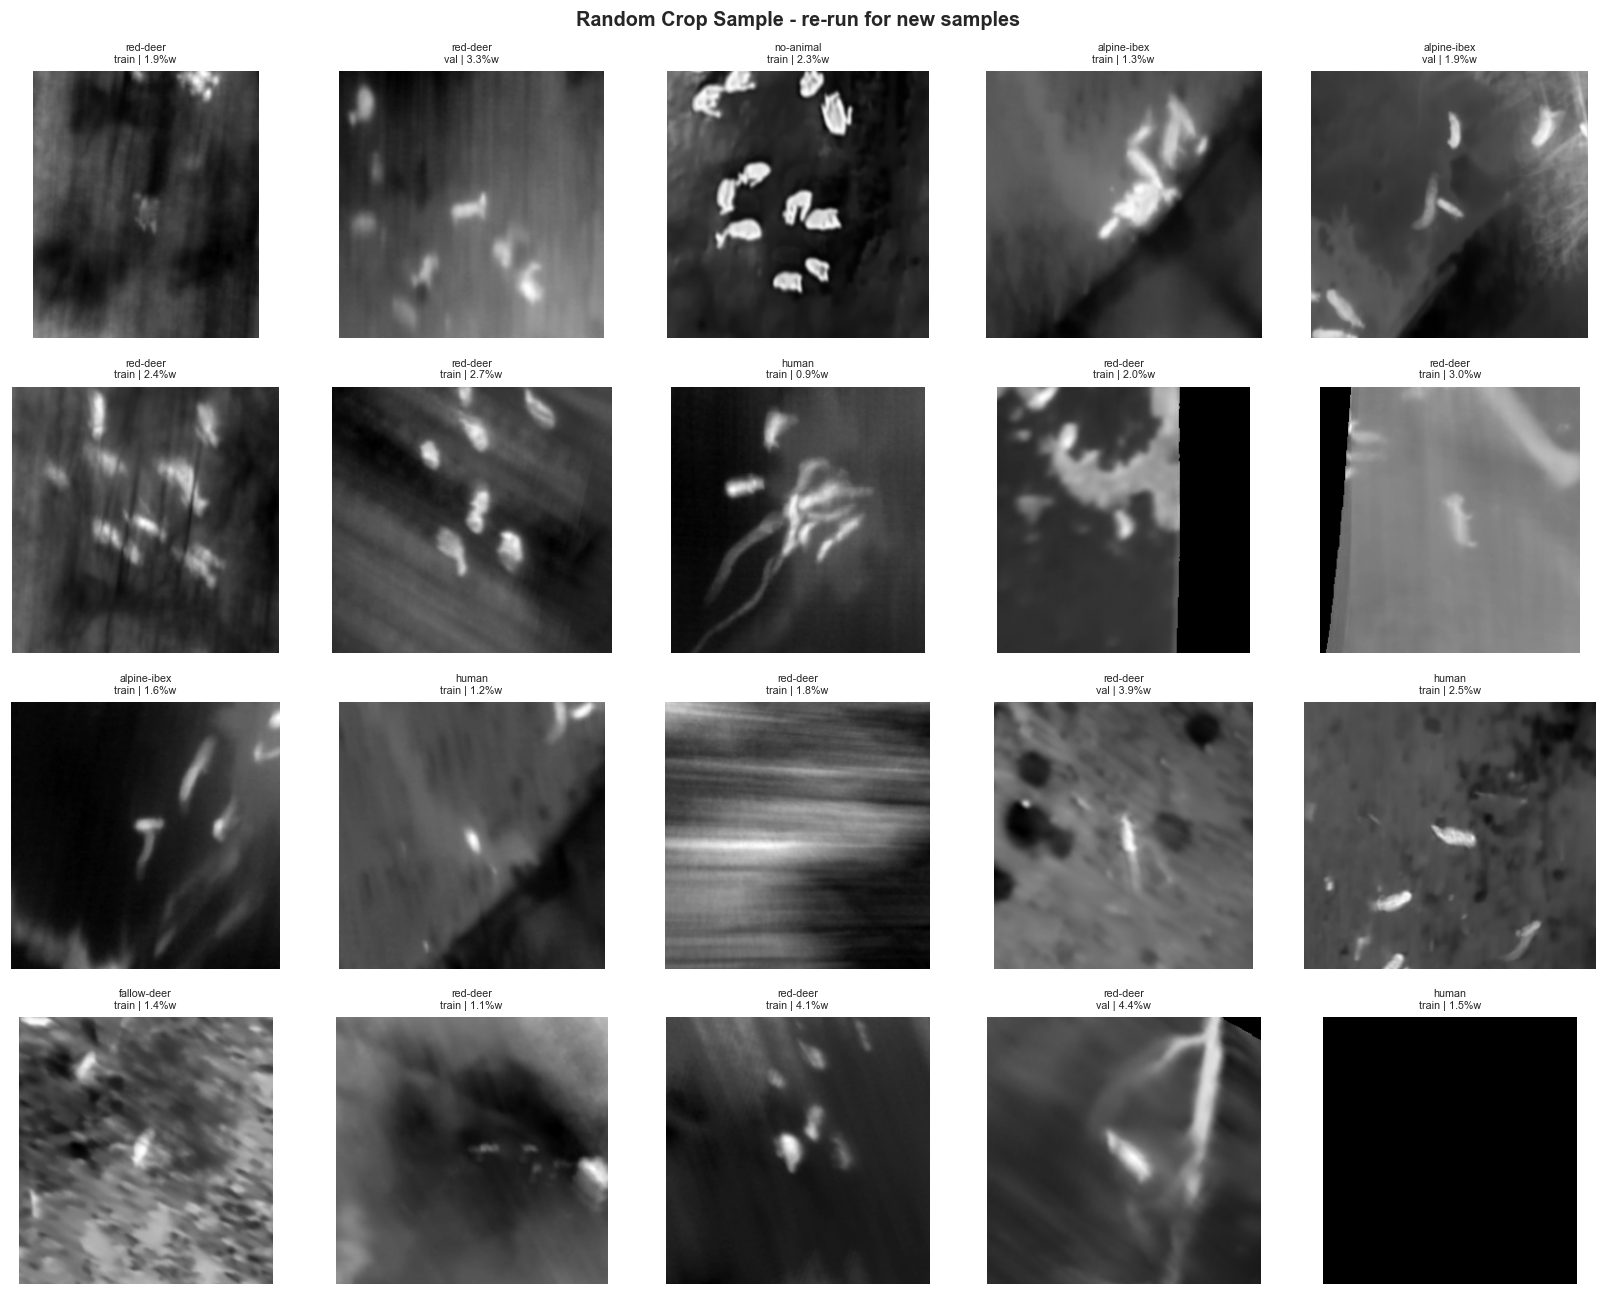


Median crop size: 2.34% × 2.29% of image
That is roughly  15px × 12px on a 640×512 image

If most crops look like tiny blobs, that is expected -
   mean box size is ~2.4% of image width (~15px on 640px).


In [12]:
N = 20
sample_crops = crops_df.sample(min(N, len(crops_df)))

cols = 5
rows = (N + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_crops.iterrows()):
    crop = cv2.imread(row["crop_path"], cv2.IMREAD_GRAYSCALE)
    if crop is not None:
        axes[i].imshow(crop, cmap="gray")
    axes[i].set_title(
        f"{row['species']}\n{row['split']} | {row['width']*100:.1f}%w",
        fontsize=7
    )
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Random Crop Sample - re-run for new samples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_PATH / "sample_crops.png", bbox_inches="tight")
plt.show()

print(f"\nMedian crop size: {crops_df['width'].median()*100:.2f}% × {crops_df['height'].median()*100:.2f}% of image")
print(f"That is roughly  {crops_df['width'].median()*640:.0f}px × {crops_df['height'].median()*512:.0f}px on a 640×512 image")
print("\nIf most crops look like tiny blobs, that is expected -")
print("   mean box size is ~2.4% of image width (~15px on 640px).")

## Measure Sharpness with the Laplacian

We score how sharp each crop is using Laplacian variance, which measures how much fine detail is in the image. A blurry crop has low variance. We mask out the dark background first so we only measure the animal.

In [13]:

# All crops are thermal - one scoring function, no modality branching needed.
#
# Strat:
#   1. Denoise with a small Gaussian blur first (important for tiny 14px crops
#      where a single noisy pixel can skew the Laplacian result significantly)
#   2. Mask out the near-black background
#   3. Compute Laplacian variance only within the animal (bright) region


THERMAL_BG_THRESHOLD = 30   # pixels below this = background (0-255 scale)

def laplacian_variance_thermal(img_path, bg_threshold=THERMAL_BG_THRESHOLD):
    """
    Returns sharpness score for a thermal crop.
    Higher = sharper animal region.
    Returns -1.0 if unreadable, 0.0 if animal region is too small.
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return -1.0

    # Step 1: Denoise - critical for tiny crops where noise dominates
    img_denoised = cv2.GaussianBlur(img, (3, 3), 0)

    # Step 2: Mask background
    mask = (img_denoised > bg_threshold).astype(np.uint8)

    # Step 3: Skip if animal region is less than 1% of crop
    if mask.sum() < 0.01 * img.size:
        return 0.0

    # Step 4: Laplacian variance on animal region only
    laplacian     = cv2.Laplacian(img_denoised, cv2.CV_64F)
    animal_pixels = laplacian[mask == 1]
    return float(animal_pixels.var())


print("Computing sharpness scores (thermal, background-masked)...")

scores = []
for i, row in crops_df.iterrows():
    scores.append(laplacian_variance_thermal(row["crop_path"]))
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{len(crops_df)} scored...")

crops_df["laplacian_score"] = scores

valid     = crops_df[crops_df["laplacian_score"] >  0]
failed    = crops_df[crops_df["laplacian_score"] == -1]
near_zero = crops_df[crops_df["laplacian_score"] == 0]

print(f"\nValid scores  : {len(valid)}")
print(f" Near-zero    : {len(near_zero)}  (animal region < 1% of crop - likely noise annotation)")
print(f"Failed        : {len(failed)}  (unreadable file)")
print(f"\nScore statistics:")
print(valid["laplacian_score"].describe().round(3))

Computing sharpness scores (thermal, background-masked)...
  1000/55386 scored...
  2000/55386 scored...
  3000/55386 scored...
  4000/55386 scored...
  5000/55386 scored...
  6000/55386 scored...
  7000/55386 scored...
  8000/55386 scored...
  9000/55386 scored...
  10000/55386 scored...
  11000/55386 scored...
  12000/55386 scored...
  13000/55386 scored...
  14000/55386 scored...
  15000/55386 scored...
  16000/55386 scored...
  17000/55386 scored...
  18000/55386 scored...
  19000/55386 scored...
  20000/55386 scored...
  21000/55386 scored...
  22000/55386 scored...
  23000/55386 scored...
  24000/55386 scored...
  25000/55386 scored...
  26000/55386 scored...
  27000/55386 scored...
  28000/55386 scored...
  29000/55386 scored...
  30000/55386 scored...
  31000/55386 scored...
  32000/55386 scored...
  33000/55386 scored...
  34000/55386 scored...
  35000/55386 scored...
  36000/55386 scored...
  37000/55386 scored...
  38000/55386 scored...
  39000/55386 scored...
  40000/55386 

## Sharpness Score Distribution

We plot the spread of sharpness scores to help us pick a cutoff between blurry and sharp.

C:\Users\dilya\AppData\Local\Temp\ipykernel_51504\3598965928.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_by_species, labels=species_order, patch_artist=True,


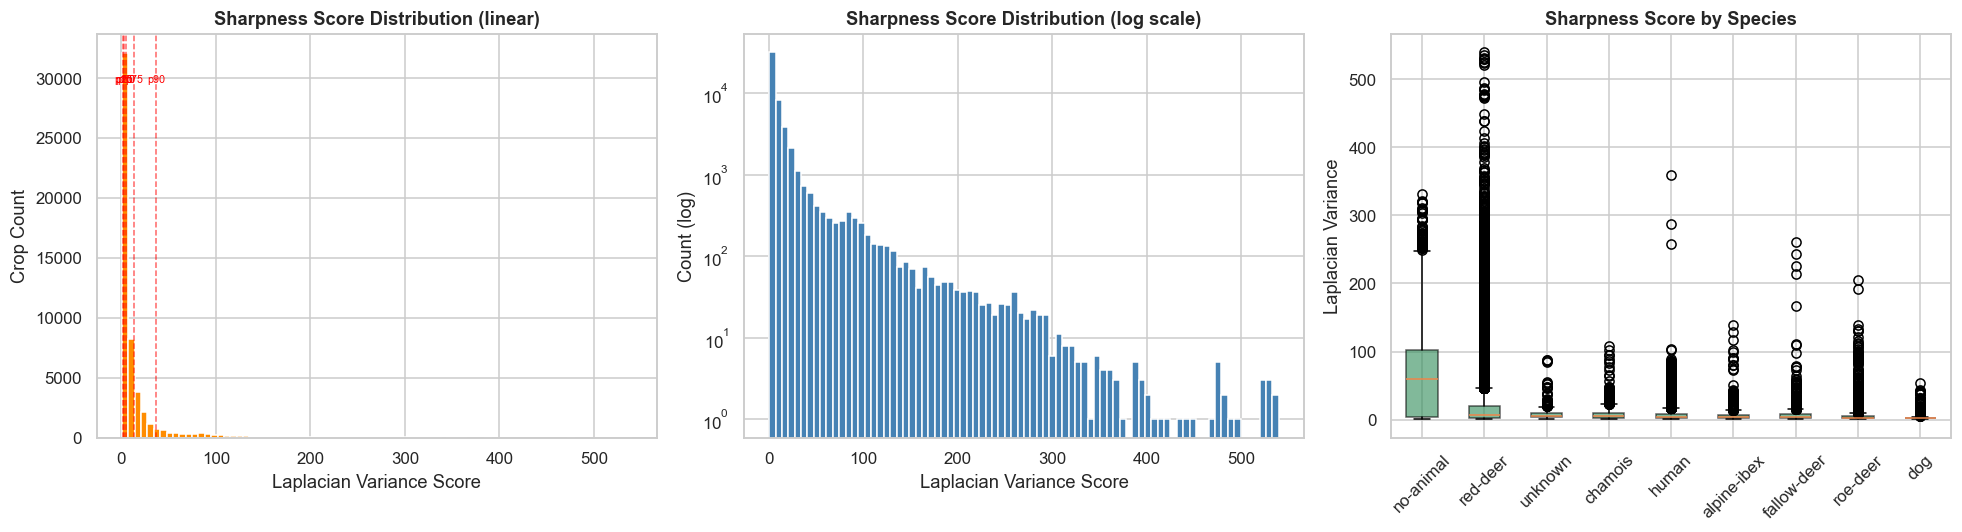

Percentile breakdown:
  p  5: 1.728
  p 10: 1.891
  p 25: 2.518
  p 50: 5.060
  p 75: 13.248
  p 90: 36.658
  p 95: 81.431


In [14]:
valid_scores = crops_df[crops_df["laplacian_score"] > 0]["laplacian_score"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear histogram
axes[0].hist(valid_scores, bins=80, color="darkorange", edgecolor="white")
axes[0].set_title("Sharpness Score Distribution (linear)", fontweight="bold")
axes[0].set_xlabel("Laplacian Variance Score")
axes[0].set_ylabel("Crop Count")
for pct in [10, 25, 50, 75, 90]:
    val = np.percentile(valid_scores, pct)
    axes[0].axvline(val, color="red", linestyle="--", alpha=0.6, linewidth=1)
    axes[0].text(val, axes[0].get_ylim()[1]*0.88,
                 f"p{pct}", fontsize=7, color="red", ha="center")

# Log scale
axes[1].hist(valid_scores, bins=80, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Sharpness Score Distribution (log scale)", fontweight="bold")
axes[1].set_xlabel("Laplacian Variance Score")
axes[1].set_ylabel("Count (log)")

# Per-species box plot (do sharper flights contain different species?)
species_order = crops_df[crops_df["laplacian_score"] > 0].groupby("species")["laplacian_score"].median().sort_values(ascending=False).index
data_by_species = [
    crops_df[(crops_df["species"] == s) & (crops_df["laplacian_score"] > 0)]["laplacian_score"].values
    for s in species_order
]
axes[2].boxplot(data_by_species, labels=species_order, patch_artist=True,
                boxprops=dict(facecolor="seagreen", alpha=0.6))
axes[2].set_title("Sharpness Score by Species", fontweight="bold")
axes[2].set_ylabel("Laplacian Variance")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_PATH / "sharpness_distribution.png", bbox_inches="tight")
plt.show()

print("Percentile breakdown:")
for pct in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  p{pct:>3}: {np.percentile(valid_scores, pct):.3f}")

## Pick the Sharp vs Blurry Threshold

We show crops at different score ranges and pick the value where blurry turns into sharp. Adjust the threshold and re-run until the boundary looks right.

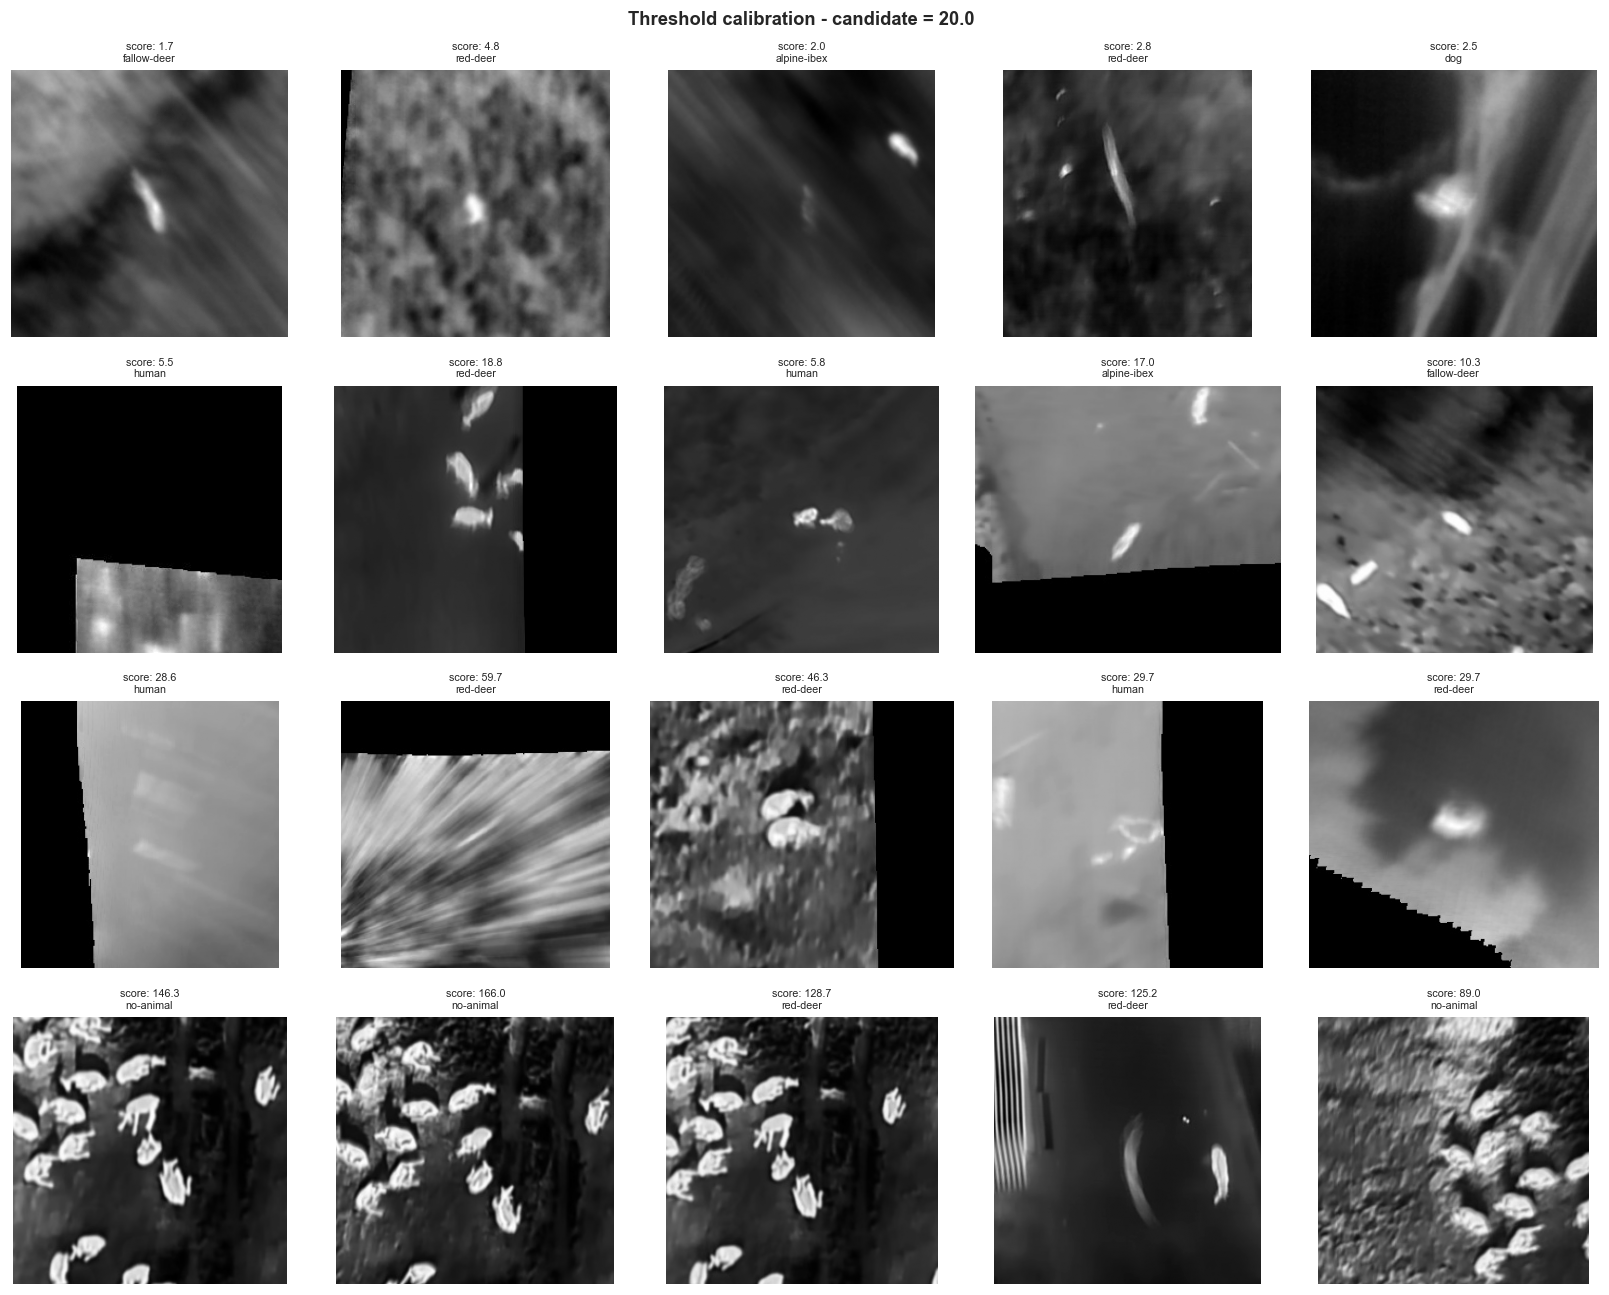

At threshold 20.0:
  Sharp  (above): 9288 (17.5%)
  Blurry (below): 43723 (82.5%)


In [18]:
# Picked 20 from the grid: just above this line animals still look defined,
# just below they go soft. 15-18 lets soft crops in, 25 leaves too few sharp ones.

CANDIDATE_THRESHOLD = 20.0  

valid = crops_df[crops_df["laplacian_score"] > 0]

bins = {
    f"Very blurry  (< {CANDIDATE_THRESHOLD*0.25:.0f})"  : valid[valid["laplacian_score"] <  CANDIDATE_THRESHOLD * 0.25],
    f"Blurry       (< {CANDIDATE_THRESHOLD:.0f})"       : valid[(valid["laplacian_score"] >= CANDIDATE_THRESHOLD * 0.25) & (valid["laplacian_score"] < CANDIDATE_THRESHOLD)],
    f"Sharp        (>= {CANDIDATE_THRESHOLD:.0f})"      : valid[(valid["laplacian_score"] >= CANDIDATE_THRESHOLD) & (valid["laplacian_score"] < CANDIDATE_THRESHOLD * 4)],
    f"Very sharp   (>= {CANDIDATE_THRESHOLD*4:.0f})"    : valid[valid["laplacian_score"] >= CANDIDATE_THRESHOLD * 4],
}

fig, axes = plt.subplots(len(bins), 5, figsize=(15, len(bins) * 3))
fig.suptitle(f"Threshold calibration - candidate = {CANDIDATE_THRESHOLD}",
             fontsize=12, fontweight="bold")

for row_idx, (label, group) in enumerate(bins.items()):
    sample = group.sample(min(5, len(group)))
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        if col_idx < len(sample):
            crop_row = sample.iloc[col_idx]
            img = cv2.imread(crop_row["crop_path"], cv2.IMREAD_GRAYSCALE)
            if img is not None:
                ax.imshow(img, cmap="gray")
                ax.set_title(
                    f"score: {crop_row['laplacian_score']:.1f}\n{crop_row['species']}",
                    fontsize=7
                )
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=140, va="center")

plt.tight_layout()
plt.savefig(REPORTS_PATH / "threshold_calibration.png", bbox_inches="tight")
plt.show()

above = (valid["laplacian_score"] >= CANDIDATE_THRESHOLD).sum()
below = (valid["laplacian_score"] <  CANDIDATE_THRESHOLD).sum()
print(f"At threshold {CANDIDATE_THRESHOLD}:")
print(f"  Sharp  (above): {above} ({100*above/len(valid):.1f}%)")
print(f"  Blurry (below): {below} ({100*below/len(valid):.1f}%)")

## Apply the Sharpness Labels

We use the chosen threshold to label every crop as sharp (1) or blurry (0).

In [19]:
SHARPNESS_THRESHOLD = CANDIDATE_THRESHOLD

def assign_sharpness(row):
    if row["laplacian_score"] < 0:
        return -1   # unreadable
    return 1 if row["laplacian_score"] >= SHARPNESS_THRESHOLD else 0

crops_df["sharpness_label"] = crops_df.apply(assign_sharpness, axis=1)

sharp    = (crops_df["sharpness_label"] == 1).sum()
blurry   = (crops_df["sharpness_label"] == 0).sum()
unscored = (crops_df["sharpness_label"] == -1).sum()
total    = len(crops_df)

print(f"Sharpness threshold : {SHARPNESS_THRESHOLD}")
print(f"\n  Sharp   (1): {sharp:>6}  ({100*sharp/total:.1f}%)")
print(f"  Blurry  (0): {blurry:>6}  ({100*blurry/total:.1f}%)")
print(f"  Failed (-1): {unscored:>6}  (unreadable images)")

print(f"\nSharpness distribution per split:")
print(crops_df.groupby("split")["sharpness_label"]
      .value_counts().unstack(fill_value=0).to_string())

print(f"\nSharpness distribution per species:")
print(crops_df.groupby("species")["sharpness_label"]
      .value_counts().unstack(fill_value=0).to_string())

Sharpness threshold : 20.0

  Sharp   (1):   9288  (16.8%)
  Blurry  (0):  46098  (83.2%)
  Failed (-1):      0  (unreadable images)

Sharpness distribution per split:
sharpness_label      0     1
split                       
test              6302   919
train            30274  6966
val               9522  1403

Sharpness distribution per species:
sharpness_label      0     1
species                     
alpine-ibex       3280    68
chamois           2203   182
dog                815    31
fallow-deer       3610   167
human            11304   633
no-animal          799  1223
red-deer         20074  6769
roe-deer          2861   183
unknown           1152    32


### Sharpness label audit - validity check 

The sharpness_label above is generated automatically by the Laplacian threshold,
not by a human. Before trusting it, we eyeball a sample: the top row should look
sharp and the bottom row should look blurry. If they don't, the threshold needs
adjusting. This is the honest way to show the auto-labels match human perception.

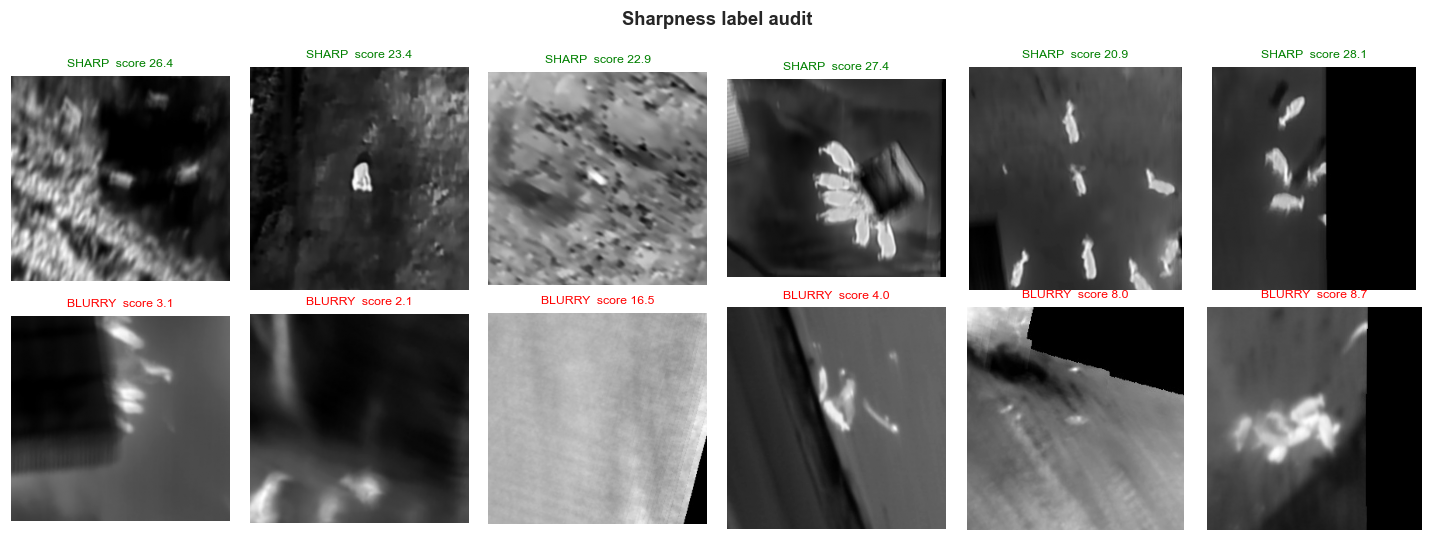

In [24]:
import matplotlib.pyplot as plt

N = 6
audit = crops_df[crops_df["sharpness_label"].isin([0, 1])]
sharp_samples  = audit[audit["sharpness_label"] == 1].sample(min(N, (audit["sharpness_label"]==1).sum()))
blurry_samples = audit[audit["sharpness_label"] == 0].sample(min(N, (audit["sharpness_label"]==0).sum()))

fig, axes = plt.subplots(2, N, figsize=(N * 2.2, 5))
fig.suptitle("Sharpness label audit",
             fontsize=12, fontweight="bold")

for col, (_, r) in enumerate(sharp_samples.iterrows()):
    im = cv2.imread(r["crop_path"], cv2.IMREAD_GRAYSCALE)
    if im is not None: axes[0, col].imshow(im, cmap="gray")
    axes[0, col].set_title("SHARP  score %.1f" % r["laplacian_score"], fontsize=8, color="green")
    axes[0, col].axis("off")

for col, (_, r) in enumerate(blurry_samples.iterrows()):
    im = cv2.imread(r["crop_path"], cv2.IMREAD_GRAYSCALE)
    if im is not None: axes[1, col].imshow(im, cmap="gray")
    axes[1, col].set_title("BLURRY  score %.1f" % r["laplacian_score"], fontsize=8, color="red")
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig(REPORTS_PATH / "sharpness_label_audit.png", bbox_inches="tight")
plt.show()


## Get the Occlusion Labels

The BAMBI class code already records whether each animal is visible or occluded in its last digit, so we read occlusion straight from there instead of labelling it by hand.

In [26]:
# whoever is gonna be doing occlusion part read this carefully and finish
# The BAMBI class_id encodes visibility in the last digit of the mapping key.
# Key format: "Q<species>-<gender>-<age>-<visibility>"
#   visibility = 1 → animal is visible    → occlusion_label = 0
#   visibility = 0 → animal is occluded   → occlusion_label = 1
#
# so we can derive occlusion automatically for any crop whose
# class_id exists in the BAMBI mapping - no manual annotation needed (but will be done additionally for comparison)


crops_df["occlusion_label"] = crops_df["class_id"].apply(occlusion_from_class_id)
# occlusion_from_class_id returns: 1=occluded, 0=visible, -1=not found

# Treat -1 (not found) as NaN
crops_df.loc[crops_df["occlusion_label"] == -1, "occlusion_label"] = np.nan

valid_occ   = crops_df["occlusion_label"].notna().sum()
missing_occ = crops_df["occlusion_label"].isna().sum()
coverage    = 100 * valid_occ / len(crops_df)

print(f"Occlusion labels derived from class_id:")
print(f"  Labeled  : {valid_occ}  ({coverage:.1f}% coverage)")
print(f"  Missing  : {missing_occ}  (unrecognised class IDs)")
print(f"\n  Visible  (0): {(crops_df['occlusion_label']==0).sum()}")
print(f"  Occluded (1): {(crops_df['occlusion_label']==1).sum()}")

print(f"\nOcclusion per species:")
labeled = crops_df[crops_df["occlusion_label"].notna()]
print(labeled.groupby("species")["occlusion_label"]
      .value_counts().unstack(fill_value=0).to_string())

if coverage >= 90:
    print(f"\n{coverage:.1f}% coverage - automatic labels are sufficient.")
else:
    print(f"\n Only {coverage:.1f}% coverage.")

Occlusion labels derived from class_id:
  Labeled  : 55386  (100.0% coverage)
  Missing  : 0  (unrecognised class IDs)

  Visible  (0): 22437
  Occluded (1): 32949

Occlusion per species:
occlusion_label    0.0    1.0
species                      
alpine-ibex       2036   1312
chamois           1746    639
dog                  0    846
fallow-deer          4   3773
human             4385   7552
no-animal         1395    627
red-deer         10032  16811
roe-deer          1769   1275
unknown           1070    114

100.0% coverage - automatic labels are sufficient.


## Combine into Four Reliability Groups

We combine sharpness and occlusion into four groups (sharp+visible, sharp+occluded, blurry+visible, blurry+occluded) and save the master crop table for Notebook 3.

In [27]:
# Final 4-way label combination: sharpness × occlusion
labeled = crops_df[
    crops_df["sharpness_label"].notna() &
    crops_df["occlusion_label"].notna() &
    (crops_df["sharpness_label"] >= 0)
].copy()

labeled["reliability_combo"] = labeled.apply(
    lambda r: (
        ("sharp" if r["sharpness_label"] == 1 else "blurry") +
        " + " +
        ("visible" if r["occlusion_label"] == 0 else "occluded")
    ),
    axis=1
)

print(f"Fully labeled crops : {len(labeled)} / {len(crops_df)} total")
print(f"\n4-way reliability distribution:")
combo_counts = labeled["reliability_combo"].value_counts()
for combo, count in combo_counts.items():
    pct = 100 * count / len(labeled)
    bar = "█" * int(pct / 2)
    print(f"  {combo:<30} {count:>6}  ({pct:.1f}%)  {bar}")

print(f"\nPer split:")
print(labeled.groupby("split")["reliability_combo"]
      .value_counts().unstack(fill_value=0).to_string())

# Save master CSV
master_path = REPORTS_PATH / "master_crops.csv"
crops_df.to_csv(master_path, index=False)
print(f"\nSaved: {master_path}")
print(f"   Columns: {list(crops_df.columns)}")

Fully labeled crops : 55386 / 55386 total

4-way reliability distribution:
  blurry + occluded               26731  (48.3%)  ████████████████████████
  blurry + visible                19367  (35.0%)  █████████████████
  sharp + occluded                 6218  (11.2%)  █████
  sharp + visible                  3070  (5.5%)  ██

Per split:
reliability_combo  blurry + occluded  blurry + visible  sharp + occluded  sharp + visible
split                                                                                    
test                            3686              2616               830               89
train                          17309             12965              4217             2749
val                             5736              3786              1171              232

Saved: reports\master_crops.csv
   Columns: ['crop_filename', 'crop_path', 'source_image', 'source_path', 'flight_id', 'split', 'class_id', 'species', 'box_idx', 'x_center', 'y_center', 'width', 'height', 'box_a

## Week 2 Summary

The main charts from this notebook in one place.

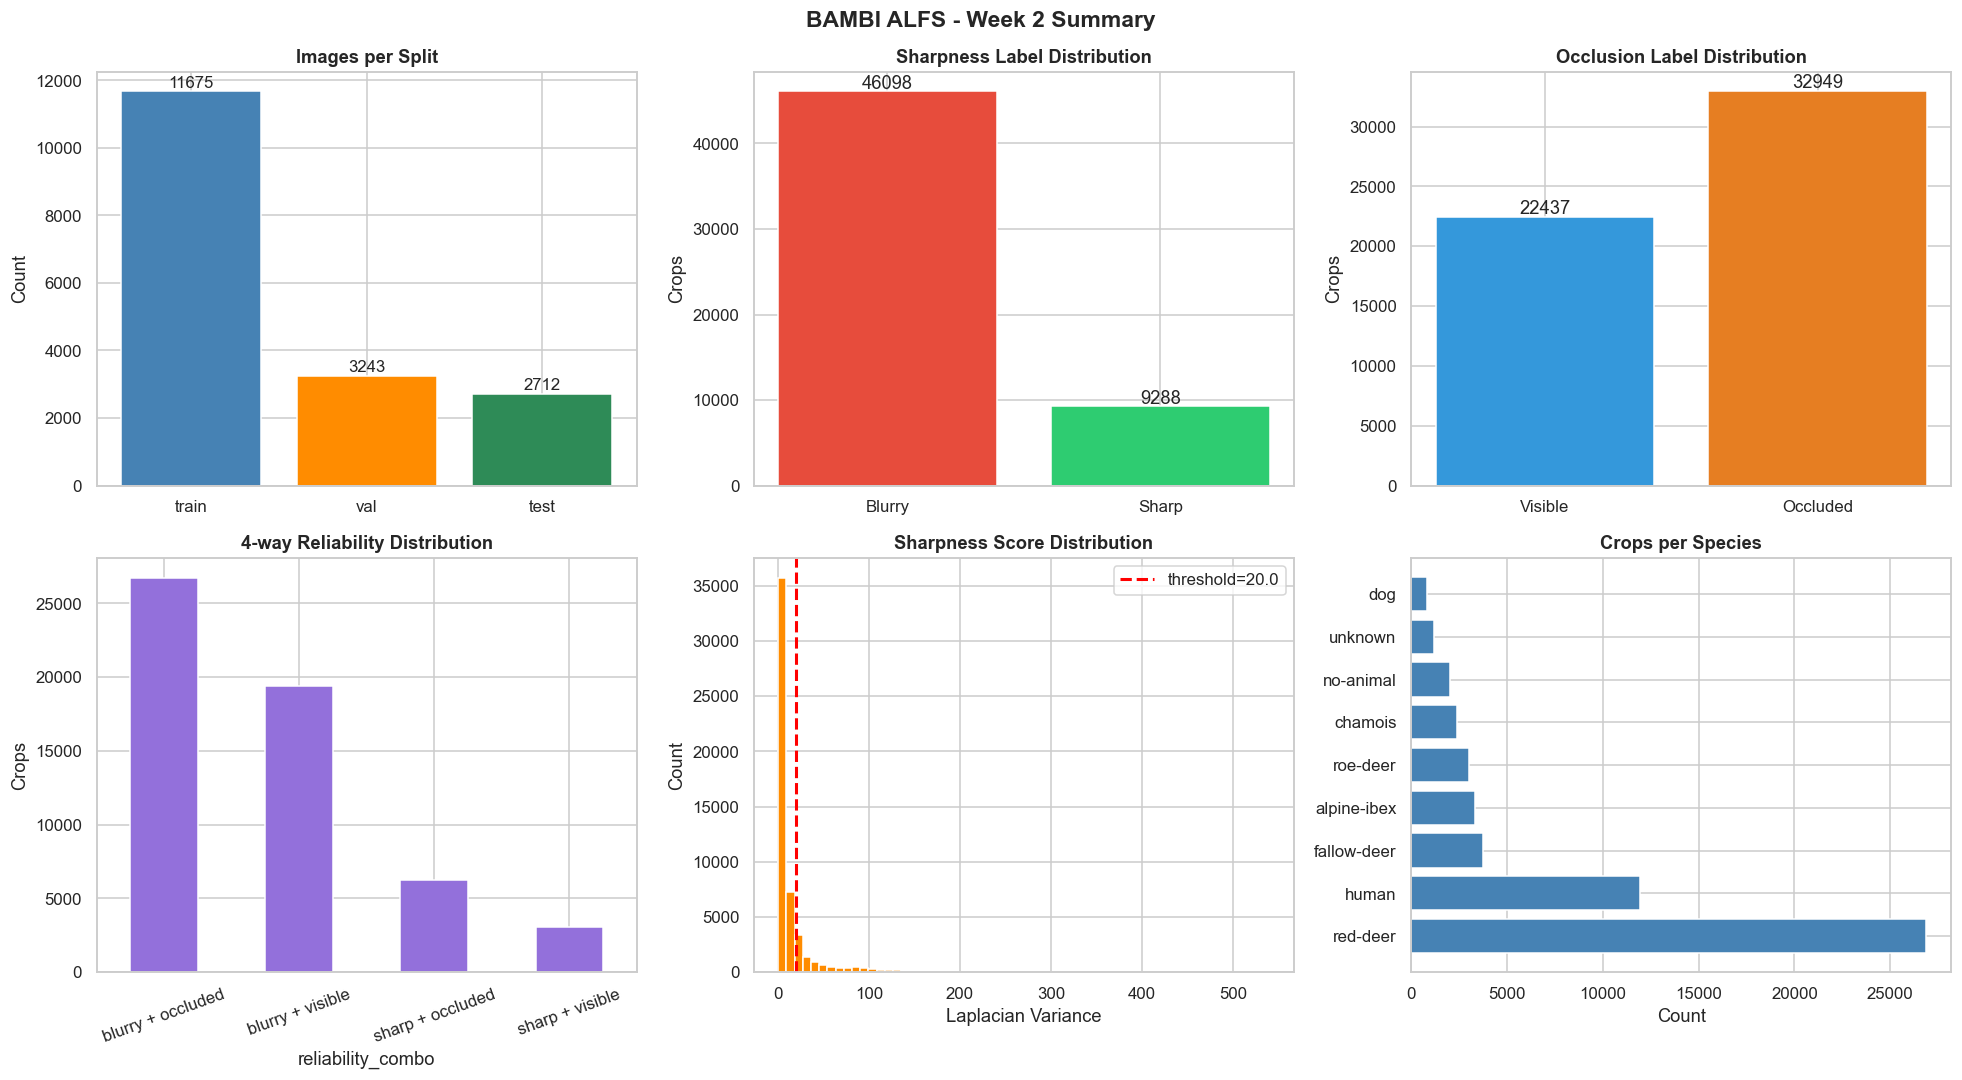

Saved: reports/week2_summary_dashboard.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("BAMBI ALFS - Week 2 Summary", fontsize=15, fontweight="bold")

# 1. Split image counts
split_counts = {s: len(list((SPLIT_PATH / s / "images").glob("*")))
                for s in ["train", "val", "test"]}
bars = axes[0,0].bar(split_counts.keys(), split_counts.values(),
                     color=["steelblue","darkorange","seagreen"])
axes[0,0].set_title("Images per Split", fontweight="bold")
axes[0,0].set_ylabel("Count")
for bar, val in zip(bars, split_counts.values()):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   val + max(split_counts.values())*0.01,
                   str(val), ha="center", fontsize=11)

# 2. Sharpness distribution
sc = crops_df["sharpness_label"].value_counts().sort_index()
sc.index = ["Failed","Blurry","Sharp"] if -1 in sc.index else ["Blurry","Sharp"]
axes[0,1].bar(sc.index, sc.values, color=["#e74c3c","#2ecc71"])
axes[0,1].set_title("Sharpness Label Distribution", fontweight="bold")
axes[0,1].set_ylabel("Crops")
for i, v in enumerate(sc.values):
    axes[0,1].text(i, v + len(crops_df)*0.005, str(v), ha="center")

# 3. Occlusion distribution
oc = crops_df["occlusion_label"].value_counts().sort_index()
labels_map = {0.0:"Visible", 1.0:"Occluded"}
oc.index   = [labels_map.get(i, str(i)) for i in oc.index]
axes[0,2].bar(oc.index, oc.values, color=["#3498db","#e67e22"])
axes[0,2].set_title("Occlusion Label Distribution", fontweight="bold")
axes[0,2].set_ylabel("Crops")
for i, v in enumerate(oc.values):
    axes[0,2].text(i, v + len(crops_df)*0.005, str(v), ha="center")

# 4. 4-way combo
if "reliability_combo" in labeled.columns:
    combo_counts.plot.bar(ax=axes[1,0], color="mediumpurple", edgecolor="white")
    axes[1,0].set_title("4-way Reliability Distribution", fontweight="bold")
    axes[1,0].set_ylabel("Crops")
    axes[1,0].tick_params(axis="x", rotation=20)

# 5. Sharpness score distribution
valid_scores = crops_df[crops_df["laplacian_score"] > 0]["laplacian_score"]
axes[1,1].hist(valid_scores, bins=60, color="darkorange", edgecolor="white")
axes[1,1].axvline(SHARPNESS_THRESHOLD, color="red", linestyle="--",
                  linewidth=2, label=f"threshold={SHARPNESS_THRESHOLD}")
axes[1,1].set_title("Sharpness Score Distribution", fontweight="bold")
axes[1,1].set_xlabel("Laplacian Variance")
axes[1,1].set_ylabel("Count")
axes[1,1].legend()

# 6. Crops per species
sp = crops_df["species"].value_counts()
axes[1,2].barh(sp.index, sp.values, color="steelblue")
axes[1,2].set_title("Crops per Species", fontweight="bold")
axes[1,2].set_xlabel("Count")

plt.tight_layout()
plt.savefig(REPORTS_PATH / "week2_summary_dashboard.png", bbox_inches="tight")
plt.show()
print("Saved: reports/week2_summary_dashboard.png")